# 05 — Predict và Submission
Load `best_model.pkl`, dự đoán `test.csv`, kiểm tra phân phối dự đoán và xem `submission.csv`.

In [1]:
from pathlib import Path
import sys, numpy as np, pandas as pd
import matplotlib.pyplot as plt
cwd=Path.cwd(); ROOT=cwd.parent if cwd.name.lower()=="notebooks" else cwd
SRC_DIR=ROOT/"src"
if str(SRC_DIR) not in sys.path: sys.path.append(str(SRC_DIR))
DATA_DIR=ROOT/"data"; EXPS_DIR=ROOT/"exps"; MODELS_DIR=ROOT/"models"/"sklearn"; SUBMISSIONS_DIR=ROOT/"submissions"
print("ROOT:",ROOT)
print("train.csv:",(DATA_DIR/"train.csv").exists())

ROOT: D:\house_price
train.csv: True


In [2]:
import joblib
model_path=MODELS_DIR/"best_model.pkl"; test_path=DATA_DIR/"test.csv"
print("Model exists:",model_path.exists()); print("Test exists:",test_path.exists())

Model exists: True
Test exists: True


In [3]:
model=joblib.load(model_path); test=pd.read_csv(test_path)
print("Test shape:",test.shape); print(model)

Test shape: (1459, 80)
Pipeline(steps=[('cleaner', HouseDataCleaner()),
                ('feature_engineering', HouseFeatureEngineer()),
                ('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  <sklearn.compose._column_transformer.make_column_selector object at 0x000001E242B12A50>),
                                                 ('cat',
                                                  Pipeline(steps=[(...
                                                                   OneHotEncoder(handle_unknown='ignore',
                                                      

In [4]:
pred_log=model.predict(test); pred=np.expm1(pred_log)
print("Count:",len(pred)); print("Min:",pred.min()); print("Max:",pred.max()); print("Mean:",pred.mean())
preview=pd.DataFrame({"Id":test["Id"],"SalePrice":pred}); display(preview.head(20))

Count: 1459
Min: 39700.34767657823
Max: 593526.4838368994
Mean: 177945.91412949262


,Id,SalePrice
0,1461,124022.360855
1,1462,161987.500813
2,1463,177198.130036
3,1464,191713.149562
4,1465,189023.437986
5,1466,177324.726165
6,1467,178321.235423
7,1468,165313.727064
8,1469,188493.477428
9,1470,123776.814613


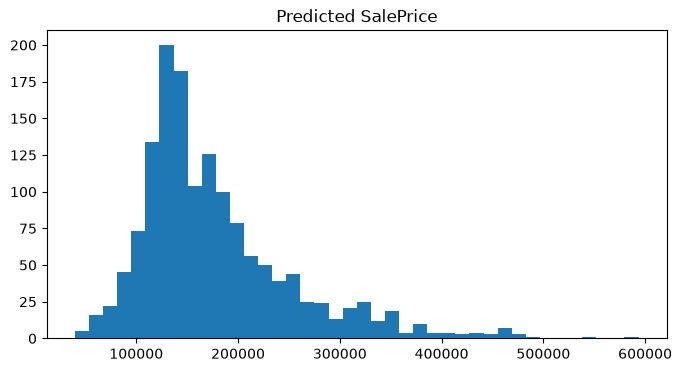

In [5]:
plt.figure(figsize=(8,4)); plt.hist(pred,bins=40); plt.title("Predicted SalePrice"); plt.show()

In [5]:
submission_path=SUBMISSIONS_DIR/"submission.csv"
if submission_path.exists(): display(pd.read_csv(submission_path).head())
else: print("Chưa có submission.csv. Chạy: python src/predict.py")

,Id,SalePrice
0,1461,124022.360855
1,1462,161987.500813
2,1463,177198.130036
3,1464,191713.149562
4,1465,189023.437986
